# Project – Big Data Processing
## News Broadcast Analysis: RTP & TVI 

**Research questions:**
1. Can we identify similar news segments across the two channels?
2. Do similar news segments across the two channels appear at same time window?

First, we start by uploading two newcasts from the same day, January 6th in this case.


In [109]:
import re
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA, NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

BASE = Path.cwd()
rtp_raw = pd.read_pickle(BASE / 'Telejornal_RTP_Jan_6_ocr.pkl')
tvi_raw = pd.read_pickle(BASE / 'Telejornal_TVI_Jan_6_ocr.pkl')

## 1. Feature Engineering

In this step, feature engineering is applied to extract two key signals from each frame: the text from the OCR detection and the wall-clock timestamp from the newcast strips. By analyzing the frames images it has been confirmed that the time is consistently shown on the screen. Aggregating text by minute then provides a straightforward basis for comparing news coverage across channels on a minute-by-minute basis.


In [110]:


def strip_html(text):
    return re.sub(r'<[^>]+>', '', text)

def extract_clock_min(ocr_list):
    """Extracting wall-clock time as minutes-since-midnight from OCR text detection."""
    for d in ocr_list:
        m = re.search(r'(2[0-2]):([0-5]\d)', d['text'])
        if m:
            return int(m.group(1)) * 60 + int(m.group(2))
    return None

def extract_text(ocr_list, min_conf=0.6):
    """Concatenate all high-confidence (above 0.6) OCR text, cleaning HTML tags if any."""
    parts = [strip_html(d['text']) for d in ocr_list if d['conf'] >= min_conf]
    return ' '.join(parts)


def preprocess(df, channel):
    df = df.copy()
    df['channel']   = channel
    df['frame_num'] = df['Frame'].str.extract(r'frame_(\d+)').astype(int)
    df['time_min']  = df['OCR'].apply(extract_clock_min)
    df['text']      = df['OCR'].apply(extract_text)
    df = df.sort_values('frame_num').reset_index(drop=True)
    return df

rtp = preprocess(rtp_raw, 'RTP')
tvi = preprocess(tvi_raw, 'TVI')

# Keep only frames with valid clock readings
rtp_t = rtp[rtp['time_min'].notna()].copy()
tvi_t = tvi[tvi['time_min'].notna()].copy()


# Show the frames and the time ranges from each news channel.
print(f"RTP valid frames: {len(rtp_t)}  | time range: {int(rtp_t.time_min.min()//60):02d}:{int(rtp_t.time_min.min()%60):02d} – {int(rtp_t.time_min.max()//60):02d}:{int(rtp_t.time_min.max()%60):02d}")
print(f"TVI valid frames: {len(tvi_t)}  | time range: {int(tvi_t.time_min.min()//60):02d}:{int(tvi_t.time_min.min()%60):02d} – {int(tvi_t.time_min.max()//60):02d}:{int(tvi_t.time_min.max()%60):02d}")

RTP valid frames: 2822  | time range: 20:00 – 20:47
TVI valid frames: 3309  | time range: 20:00 – 21:12


## 2. Text aggregation per minute window

Here we are aggregating the detected words, with high confidence, by minute for further analysis.

In [111]:
def aggregate_text_by_minute(df):
    '''Grouping all words by minute after midnight.'''
    df = df[df['time_min'].notna()].copy()
    df['minute'] = df['time_min'].astype(int)
    grouped = df.groupby('minute')['text'].apply(lambda x: ' '.join(x)).reset_index()
    grouped.columns = ['minute', 'text']
    return grouped

rtp_min = aggregate_text_by_minute(rtp_t)
tvi_min = aggregate_text_by_minute(tvi_t)

#Showing the overlapping minutes between the two broadcasts. This will be used to analyze whether they 
#present the same topics in similar time frames or not.
overlap = set(rtp_min['minute']) & set(tvi_min['minute'])
print(f"Overlapping minutes: {len(overlap)}")
print(f"RTP minutes: {sorted(rtp_min.minute.tolist())}")
print(f"TVI minutes: {sorted(tvi_min.minute.tolist())}")


Overlapping minutes: 48
RTP minutes: [1200, 1201, 1202, 1203, 1204, 1205, 1206, 1207, 1208, 1209, 1210, 1211, 1212, 1213, 1214, 1215, 1216, 1217, 1218, 1219, 1220, 1221, 1222, 1223, 1224, 1225, 1226, 1227, 1228, 1229, 1230, 1231, 1232, 1233, 1234, 1235, 1236, 1237, 1238, 1239, 1240, 1241, 1242, 1243, 1244, 1245, 1246, 1247]
TVI minutes: [1200, 1201, 1202, 1203, 1204, 1205, 1206, 1207, 1208, 1209, 1210, 1211, 1212, 1213, 1214, 1215, 1216, 1217, 1218, 1219, 1220, 1221, 1222, 1223, 1224, 1225, 1226, 1227, 1228, 1229, 1230, 1231, 1232, 1233, 1234, 1235, 1236, 1237, 1238, 1239, 1240, 1241, 1242, 1243, 1244, 1245, 1246, 1247, 1248, 1262, 1263, 1264, 1265, 1266, 1267, 1268, 1269, 1270, 1271, 1272]


## 3. TF-IDF + Cosine Similarity heatmap

Here we are building TF-IDF vectors, after removing portuguese stop words, and then comparing their similarity by using cosine similarity. As a result, we get a RTP minutes x TVI minutes matrix with comparison scores to detect when in the broadcast the same news (topics/text) are addressed or presented.

Given this, we can answer our first question regarding if similar topics across both channels can be identified.

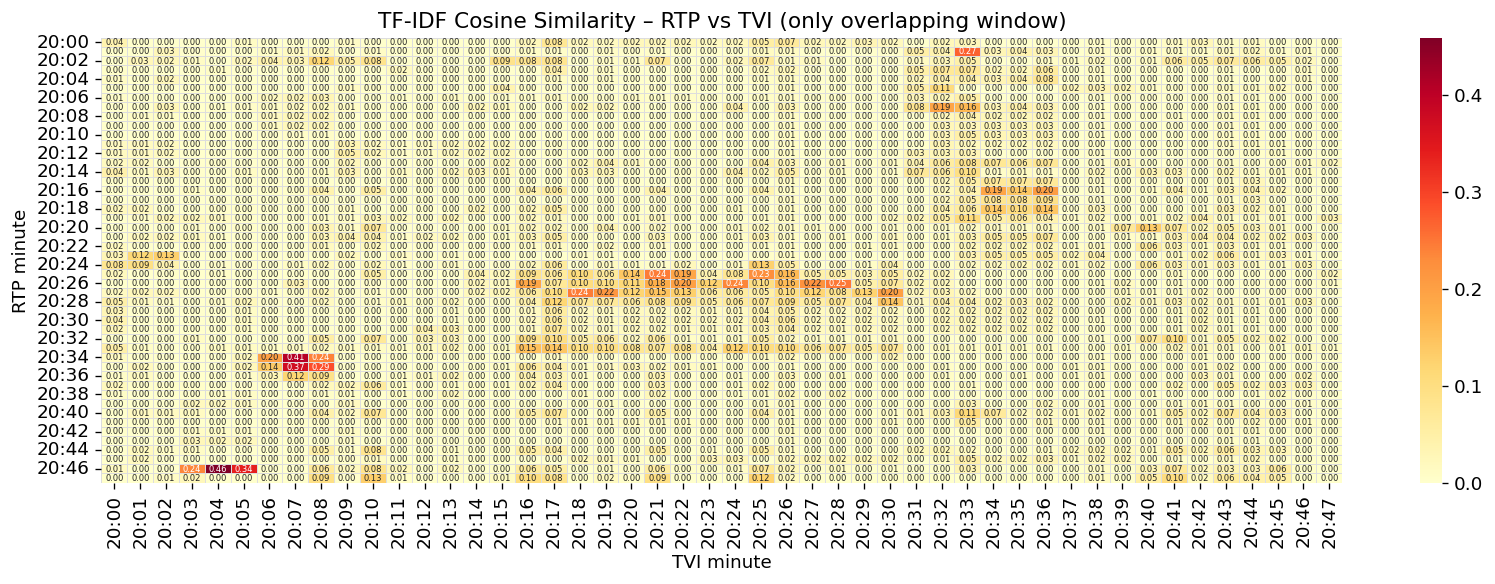

In [112]:
# Portuguese stop-words to be removed in the TF-IDF
PT_STOP = set([
    'a','ao','aos','aquela','aquelas','aquele','aqueles','aquilo','as','até',
    'com','como','da','das','de','dela','delas','dele','deles','depois','do',
    'dos','e','é','ela','elas','ele','eles','em','entre','era','essa','essas',
    'esse','esses','esta','estas','este','estes','eu','foi','foram','há',
    'isso','isto','já','lhe','lhes','me','mais','mas','me','mesmo','meu','meus',
    'minha','minhas','muito','na','não','nas','nem','no','nos','nós','nossa',
    'nossas','nosso','nossos','num','numa','o','os','ou','para','pela','pelas',
    'pelo','pelos','por','qual','quando','que','se','sem','ser','seu','seus',
    'só','sua','suas','também','te','tem','têm','tinha','todo','todos','tu',
    'um','uma','uns','umas','você','vós','à','às','é','tvi','rtp','telejornal',
])

# Building a joint corpus for TF-IDF (all minutes and text from both channels)
rtp_docs = list(rtp_min['text'])
tvi_docs = list(tvi_min['text'])
all_docs = rtp_docs + tvi_docs

# TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    stop_words=list(PT_STOP),
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True,
    token_pattern=r'[A-Za-záàâãéèêíïóôõúüçÁÀÂÃÉÈÊÍÏÓÔÕÚÜÇ]{3,}',
)
tfidf_all = vectorizer.fit_transform(all_docs)

#Separation between RTP and TVI minutes.
n_rtp = len(rtp_docs)
tfidf_rtp = tfidf_all[:n_rtp]
tfidf_tvi = tfidf_all[n_rtp:]

# Cosine similarity: rows = RTP minutes, cols = TVI minutes
sim_matrix = cosine_similarity(tfidf_rtp, tfidf_tvi)

#Creates the RTP minutes X TVI minutes dataframe.
sim_df = pd.DataFrame(
    sim_matrix,
    index=[f"{int(m//60):02d}:{int(m%60):02d}" for m in rtp_min['minute']],
    columns=[f"{int(m//60):02d}:{int(m%60):02d}" for m in tvi_min['minute']],
)

# Plot – restrict TVI columns to the overlapping window of minutes.
overlap_cols = [f"{int(m//60):02d}:{int(m%60):02d}" for m in sorted(overlap)]
sim_overlap = sim_df[overlap_cols]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    sim_overlap, ax=ax, cmap='YlOrRd', vmin=0, vmax=sim_overlap.values.max(),
    linewidths=0.3, linecolor='#ddd', annot=True, fmt='.2f', annot_kws={'size': 5},
)
ax.set_title('TF-IDF Cosine Similarity – RTP vs TVI (only overlapping window)', fontsize=13)
ax.set_xlabel('TVI minute')
ax.set_ylabel('RTP minute')
plt.tight_layout()
#plt.savefig(f'{BASE}\\fig_similarity_heatmap.png', bbox_inches='tight')
plt.show()




## 4. Clusterizing the topics shared between the high similarity pairs.

In [115]:
#Defined similarity threshold
THRESHOLD = 0.15
#Get the words/bi-gram obtained by the TF-IDF vectorizer.
feature_names = vectorizer.get_feature_names_out()

def top_terms_doc(doc_vec, n=6):
    arr = np.array(doc_vec.todense()).flatten()
    idx = arr.argsort()[::-1][:n]
    return [feature_names[i] for i in idx if arr[i] > 0]

#Filter the sim_matrix only by those above the threshold.
high_sim_pairs = []
for i in range(sim_matrix.shape[0]):
    for j in range(sim_matrix.shape[1]):
        if sim_matrix[i, j] >= THRESHOLD:
            high_sim_pairs.append({
                'rtp_idx': i,
                'tvi_idx': j,
                'rtp_min': rtp_min.iloc[i]['minute'],
                'tvi_min': tvi_min.iloc[j]['minute'],
                'similarity': sim_matrix[i, j],
            })

pairs_df = pd.DataFrame(high_sim_pairs).sort_values('similarity', ascending=False).reset_index(drop=True)
pairs_df['rtp_lbl'] = pairs_df['rtp_min'].apply(lambda m: f"{int(m//60):02d}:{int(m%60):02d}")
pairs_df['tvi_lbl'] = pairs_df['tvi_min'].apply(lambda m: f"{int(m//60):02d}:{int(m%60):02d}")
print(f"Pairs with similarity >= {THRESHOLD}: {len(pairs_df)}")

# Helper: terms strong in BOTH documents (element-wise min of TF-IDF scores)
def shared_top_terms(rtp_vec, tvi_vec, n=6):
    arr_r = np.array(rtp_vec.todense()).flatten()
    arr_t = np.array(tvi_vec.todense()).flatten()
    shared = np.minimum(arr_r, arr_t)
    idx = shared.argsort()[::-1][:n]
    return [feature_names[k] for k in idx if shared[k] > 0]

# K-Means clustering on the involved documents only.
# L2-normalise so K-Means uses cosine-like distance instead of Euclidean.
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

unique_rtp_idx = sorted(pairs_df['rtp_idx'].unique())
unique_tvi_idx = sorted(pairs_df['tvi_idx'].unique())
involved_idx   = unique_rtp_idx + [n_rtp + j for j in unique_tvi_idx]
X_high      = tfidf_all[involved_idx]
X_high_norm = normalize(X_high, norm='l2')

N_CLUSTERS = 6
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10, max_iter=300)
kmeans.fit(X_high_norm)
labels = kmeans.labels_

# Top terms per cluster 
print("\n=== Topic Clusters (K-Means on high-similarity documents) ===")
for t in range(N_CLUSTERS):
    centroid = kmeans.cluster_centers_[t]
    top_i = centroid.argsort()[::-1][:8]
    words = [feature_names[k] for k in top_i if centroid[k] > 0]
    print(f"  Cluster {t+1}: {' | '.join(words)}")
print()

# Map each unique RTP document to its cluster label.
rtp_cluster_map = {
    rtp_i: int(labels[pos])
    for pos, rtp_i in enumerate(unique_rtp_idx)
}

# Summary table
print(f"{'RTP':<6} {'TVI':<6} {'sim':>6}  {'Cluster':>9}  {'Shared top terms'}")
print("-" * 110)
for _, row in pairs_df.iterrows():
    cluster = rtp_cluster_map.get(int(row['rtp_idx']), -1) + 1
    r_vec   = tfidf_rtp[int(row['rtp_idx'])]
    t_vec   = tfidf_tvi[int(row['tvi_idx'])]
    terms   = shared_top_terms(r_vec, t_vec)
    print(f"{row['rtp_lbl']:<6} {row['tvi_lbl']:<6} {row['similarity']:>6.3f}  Cluster {cluster}    {', '.join(terms)}")

Pairs with similarity >= 0.15: 28

=== Topic Clusters (K-Means on high-similarity documents) ===
  Cluster 1: venezuela | colômbia | trump | militares | fronteira | futuro venezuela | futuro | crise venezuela
  Cluster 2: seguro | presidenciais | josé seguro | antónio | seguro diz | presidenciais seguro | antónio josé | candidato
  Cluster 3: presidenciais | marques mendes | marques | cotrim | mendes | cavaco | cotrim figueiredo | república
  Cluster 4: rejeitam defesa | rejeitam | governante | oficiosos rejeitam | oficiosos | defensores oficiosos | defesa governante | defensores
  Cluster 5: operação marquês | marquês | advogada | operação | marquês ter | advogada oficiosa | oficiosa | cross
  Cluster 6: feridos | acidente | frança | pessoas morreram | morreram | portuguesa | cidadã portuguesa | cidadã

RTP    TVI       sim    Cluster  Shared top terms
--------------------------------------------------------------------------------------------------------------
20:46  20:04   0.459  C

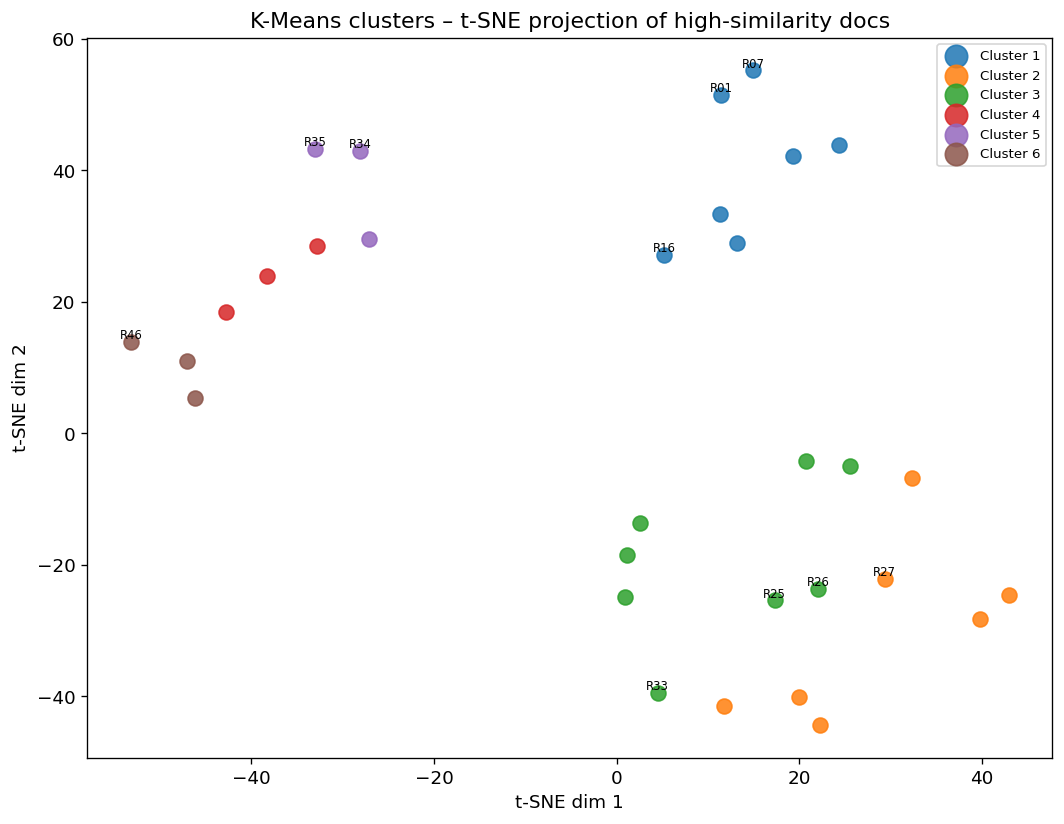

In [118]:
from sklearn.manifold import TSNE

cluster_colors = plt.cm.tab10.colors


tsne = TSNE(n_components=2, perplexity=5, random_state=42, max_iter=1000)
X_2d_tsne = tsne.fit_transform(X_high_norm.toarray())

fig, ax = plt.subplots(figsize=(9, 7))
for c in range(N_CLUSTERS):
    mask = labels == c
    ax.scatter(X_2d_tsne[mask, 0], X_2d_tsne[mask, 1],
               color=cluster_colors[c], label=f'Cluster {c+1}', s=80, alpha=0.85)

for pos, rtp_i in enumerate(unique_rtp_idx):
    lbl = f"R{int(rtp_min.iloc[rtp_i]['minute'] % 60):02d}"
    ax.annotate(lbl, (X_2d_tsne[pos, 0], X_2d_tsne[pos, 1]), fontsize=7, ha='center', va='bottom')

ax.set_title('K-Means clusters – t-SNE projection of high-similarity docs')
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.legend(fontsize=8, markerscale=1.5)
plt.tight_layout()
plt.savefig(BASE / 'fig_kmeans_tsne.png', bbox_inches='tight')
plt.show()